# Supervisor Architecture

In [1]:
from typing import Annotated, TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

    user_input : str

    paths = {
        "plan_path" : str,
        "design_path" : str,
    }

    status = {
        "planning" : str,
        "designing" : str
    }

    next_agent : str

    current_stager : str
    completed_stages : list[str]

    canvas : str

In [4]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(
    model = "gpt-4.1-mini",
    temperature = 0.5
)

In [6]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [7]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "1"}}

In [8]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [9]:
from tools.planner import create, append, rewrite, read_plan, summarize_plan, update_plan
from tools.designer import create, append, rewrite, read_design

In [10]:
design_tools = [create, append, rewrite, read_design]
plan_tools = [create, append, rewrite, read_plan, summarize_plan, update_plan]

In [11]:
def orchestator(state:State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [12]:
designer = llm.bind_tools(tools = design_tools)

def desiging_agent(state:State):
    response = designer.invoke(state["messages"])
    return {"messages": [response]}

In [13]:
planner = llm.bind_tools(tools = plan_tools)

def planning_agent(state:State):
    response = planner.invoke(state["messages"])
    return {"messages": [response]}

In [15]:
graph_builder = StateGraph(State)

graph_builder.add_node("orchestrator", orchestator)
graph_builder.add_node("designer", desiging_agent)
graph_builder.add_node("planner", planning_agent)

graph_builder.add_edge("orchestrator","designer")
graph_builder.add_edge("orchestrator", "planner")
graph_builder.add_edge("planner", "designer")

graph_builder.add_edge("designer", "orchestrator")
graph_builder.add_edge("planner", "orchestrator")
graph_builder.add_edge(START, "orchestrator")
graph_builder.add_edge("orchestrator", END)

graph = graph_builder.compile(checkpointer=memory)


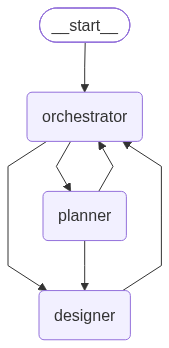

In [16]:
graph